<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/nlp-with-transformers/blob/main/08_model-compression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

In [ ]:
# 코랩이나 캐글을 사용한다면 이 셀의 주석을 제거하고 실행하세요.
!git clone https://github.com/kikim6114/nlp-practice-2025.git
%cd nlp-practice-2025
from install import *
install_requirements(chapter=8)

Cloning into 'nlp-practice-2025'...
remote: Enumerating objects: 790, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 790 (delta 49), reused 41 (delta 26), pack-reused 719 (from 3)
Receiving objects: 100% (790/790), 213.89 MiB | 23.75 MiB/s, done.
Resolving deltas: 100% (215/215), done.
Updating files: 100% (684/684), done.
/content/nlp-practice-2025
⏳ Installing base requirements ...
✅ Base requirements installed!
Using transformers v4.52.4
Using datasets v2.14.4
Using accelerate v1.7.0
Using optuna v4.3.0
Using onnxruntime v1.22.0
Using onnx v1.18.0
No GPU was detected! This notebook can be *very* slow without a GPU 🐢
Go to Runtime > Change runtime type and select a GPU hardware accelerator.


In [ ]:
!pip uninstall gcsfs
!pip install gcsfs==2025.3.0
!pip install fsspec==2025.3.0
!pip install -U huggingface_hub datasets

Found existing installation: gcsfs 2025.3.2
Uninstalling gcsfs-2025.3.2:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/gcsfs-2025.3.2.dist-info/*
    /usr/local/lib/python3.11/dist-packages/gcsfs/*
Proceed (Y/n)? 
  Successfully uninstalled gcsfs-2025.3.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4


# 8. 효율적인 트랜스포머 구축

#### 작지만 빠르고 정확도 높은 모델이 필요하다면?
#### 예측 속도를 높이고 트랜스포머 모델의 메모리 사용량을 줄이는 기술 4 가지:
- 지식 정제(Knowledge Distillation)
- 양자화(Quantization)
- 가지치기(Pruning)
- ONNX 포맷과 ONNX 런타임(ORT)을 사용한 그래프 최적화(Graph Optimization)

<img alt="Scaling BERT at Roblox" caption="How Roblox scaled BERT with knowledge distillation, dynamic padding, and weight quantization (photo courtesy of Roblox employees Quoc N. Le and Kip Kaehler)" src="https://github.com/kikim6114/nlp-practice-2025/blob/main/images/chapter08_roblox.png?raw=1" width="800" id="roblox"/>
<p align="center">[그림 8-1] Roblox가 지식 정제, 동적 패딩, 가중치 양자화로 BERT를 스케일링한 예(로블록스 직원인 Quoc N. Le와 Kip Kaehler 제공)
</p>
<br>
* 지식 정제와 양자화를 연결해 레이턴시와 BERT 분류기의 처리 성능을 30배 이상 향상시킴

## 8.1 의도 탐지 예제
- 금융사 콜센터 전용 텍스트 기반 어시스턴스 시스템 구축하기
- 의도 탐지(Intent Detection):
  - 텍스트 기반 어시스턴스 시스템에서 중요한 구성 요소
  - 사용자 쿼리를 사전에 정의된 일련의 행동이나 의도로 분류하고 후속 작업(예: 렌트가 예약이면 렌트가 예약 관련 대화로 전환)
  - 대화 유지를 위해서 latency가 낮아야 한다
  - 사용자가 정의된 의도에 속하지 않은 쿼리를 제공하면 이에 대하여 응답을 출력해야 한다.

<img alt="Out of Scope Query" width="300" caption="Three exchanges between a human (right) and a text-based assistant (left) for personal finance (courtesy of Stefan Larson et al.)" src="https://github.com/rickiepark/nlp-with-transformers/blob/main/images/chapter08_oos.png?raw=1" id="oos"/>
<p>[그림 8-2] 사람(오른쪽)과 텍스트 기반 어시스턴트(왼쪽)가 개인 금융정보에 대해 나눈 대화(Stefan Larson 등이 제공)
</p>

##### 기준 모델: CLINIC150 dataset에서 fine-tuning된 BERT base 모델(정확도: 94%)
##### CLINIC150 dataset:
- 150 개 intent classes
- 22,500 queries for 10 개 domains
- 1,200 queries for oos class(Out-Of-Scope class)

In [ ]:
from transformers import pipeline
# 허깅페이스 허브에서 미세 튜닝한 모데을 다운로드 하고 위 사진의 태스크를 진행
bert_ckpt = "transformersbook/bert-base-uncased-finetuned-clinc"
pipe = pipeline("text-classification", model=bert_ckpt)

config.json:   0%|          | 0.00/8.18k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
query = """Hey, I'd like to rent a vehicle from Nov 1st to Nov 15th in
Paris and I need a 15 passenger van"""
pipe(query)

[{'label': 'car_rental', 'score': 0.5490031838417053}]

## 8.2 벤치마크 클래스 만들기
#### 트랜스포머를 제품 환경에 배포하기 위해 절충해야 할 제약 조건들:
- 모델 성능
- 레이턴시
- 메모리  


##### 이러한 제약들을 다양한 압축 기법으로 최적화하는 방법을 알아본다.

In [ ]:
class PerformanceBenchmark:
    def __init__(self, pipeline, dataset, optim_type="BERT baseline"):
        self.pipeline = pipeline
        self.dataset = dataset
        self.optim_type = optim_type

    def compute_accuracy(self):
        # 나중에 정의합니다
        pass

    def compute_size(self):
        # 나중에 정의합니다
        pass

    def time_pipeline(self):
        # 나중에 정의합니다
        pass

    def run_benchmark(self):
        metrics = {}
        metrics[self.optim_type] = self.compute_size()
        metrics[self.optim_type].update(self.time_pipeline())
        metrics[self.optim_type].update(self.compute_accuracy())
        return metrics

#### 테스트셋에서 모델 정확도 계산

In [ ]:
from datasets import load_dataset

clinc = load_dataset("clinc_oos", "plus")  # "plus": oos 훈련샘플이 담긴 subset

README.md:   0%|          | 0.00/24.0k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/77.8k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/136k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15250 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5500 [00:00<?, ? examples/s]

In [ ]:
clinc

DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5500
    })
})

In [ ]:
import pandas as pd
pd.DataFrame(clinc["test"][40:45])

,text,intent
0,i would like to transfer $100 from my checking...,133
1,help me transfer $100 from my checking to savi...,133
2,transfer $100 from my checking to saving account,133
3,can you please help me move $100 from my check...,133
4,please move $100 from my checking to saving ac...,133


In [ ]:
sample = clinc["test"][42]
sample

{'text': 'transfer $100 from my checking to saving account', 'intent': 133}

In [ ]:
clinc["test"].features["intent"]

ClassLabel(names=['restaurant_reviews', 'nutrition_info', 'account_blocked', 'oil_change_how', 'time', 'weather', 'redeem_rewards', 'interest_rate', 'gas_type', 'accept_reservations', 'smart_home', 'user_name', 'report_lost_card', 'repeat', 'whisper_mode', 'what_are_your_hobbies', 'order', 'jump_start', 'schedule_meeting', 'meeting_schedule', 'freeze_account', 'what_song', 'meaning_of_life', 'restaurant_reservation', 'traffic', 'make_call', 'text', 'bill_balance', 'improve_credit_score', 'change_language', 'no', 'measurement_conversion', 'timer', 'flip_coin', 'do_you_have_pets', 'balance', 'tell_joke', 'last_maintenance', 'exchange_rate', 'uber', 'car_rental', 'credit_limit', 'oos', 'shopping_list', 'expiration_date', 'routing', 'meal_suggestion', 'tire_change', 'todo_list', 'card_declined', 'rewards_balance', 'change_accent', 'vaccines', 'reminder_update', 'food_last', 'change_ai_name', 'bill_due', 'who_do_you_work_for', 'share_location', 'international_visa', 'calendar', 'translate',

In [ ]:
len(clinc["test"].features["intent"].names)

151

`ClassLabel`: HuggingFace의 datasets 라이브러리에서 사용되는 기능. 범주형 데이터가 포함된 데이터셋의 열을 나타내는 데 사용되며, 각 범주는 레이블과 연관됨. 레이블은 내부적으로 정수로 저장되며, 정수 표현과 문자열 레이블 간 변환을 위한 메서드 제공.

In [ ]:
intents = clinc["test"].features["intent"]
intents.int2str(sample["intent"])

'transfer'

#### `PerformanceBenchmark`의 `computer_accuracy()` 구현
##### 🤗 [`evaluate`](https://pypi.org/project/evaluate/):  모델을 평가하고 비교하며, 성능 리포트를 보다 쉽고 표준화된 방식으로 만들어 주는 라이브러리

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.0 MB/s eta 0:00:00


In [ ]:
import evaluate

accuracy_score = evaluate.load("accuracy")  # 정확도 metric 로드

In [ ]:
def compute_accuracy(self):
    """PerformanceBenchmark.compute_accuracy() 메서드를 오버라이드"""
    preds, labels = [], []
    for example in self.dataset:
        pred = self.pipeline(example["text"])[0]["label"]  # pipeline 출력 내용 예:  [{'label': 'car_rental', 'score': 0.549003541469574}]
        label = example["intent"]
        preds.append(intents.str2int(pred))
        labels.append(label)
    accuracy = accuracy_score.compute(predictions=preds, references=labels)
    print(f"테스트 세트 정확도 - {accuracy['accuracy']:.3f}")
    return accuracy

PerformanceBenchmark.compute_accuracy = compute_accuracy

##### `torch.save()` 함수를 사용해 모델을 디스크에 직렬화하고 크기를 계산  
##### `state_dict()` 메소드는 모델의 층과 학습가능 파라미터를 매핑하는 딕셔너리 반환  

In [ ]:
list(pipe.model.state_dict().items())[42]

('bert.encoder.layer.2.attention.self.value.bias',
 tensor([-2.7834e-02,  4.9434e-02,  8.3551e-02,  4.1092e-02,  6.0157e-01,
          1.1774e-01, -5.2112e-02, -6.5143e-02, -2.9358e-02, -4.2250e-02,
          7.9177e-02,  8.0409e-02,  2.9921e-03,  1.7816e-01, -5.0480e-02,
         -1.5634e-01, -2.1707e-02,  1.4381e-02,  2.5132e-02, -2.4110e-02,
         -1.9183e-01, -7.8657e-02,  5.0709e-02,  3.3632e-02, -3.1946e-02,
          1.1616e-01,  9.2720e-02, -1.1787e-01,  2.3233e-01, -1.2678e-02,
         -1.3138e-01, -4.0024e-02,  7.4823e-02, -5.4148e-02, -1.5184e-01,
         -7.4407e-02,  1.1559e-01,  8.2729e-02, -1.3787e-01,  8.3528e-02,
          1.2154e-01,  1.6880e-02, -5.6629e-02, -3.9295e-02,  5.3725e-02,
          6.8602e-02, -1.1294e-01,  4.4001e-02, -2.5884e-01,  1.6767e-01,
          1.8316e-01,  5.6272e-02, -3.6874e-02, -2.7938e-02, -9.3204e-02,
         -7.5239e-03,  4.1141e-02, -1.1542e-02, -9.9749e-02, -3.0910e-02,
          4.1398e-02, -4.4389e-02, -2.6279e-02,  7.2100e-02, 

In [ ]:
for i, param_tensor in enumerate(pipe.model.state_dict()):
    print(f"{i}\t{param_tensor}\t{pipe.model.state_dict()[param_tensor].size()}")

0	bert.embeddings.word_embeddings.weight	torch.Size([30522, 768])
1	bert.embeddings.position_embeddings.weight	torch.Size([512, 768])
2	bert.embeddings.token_type_embeddings.weight	torch.Size([2, 768])
3	bert.embeddings.LayerNorm.weight	torch.Size([768])
4	bert.embeddings.LayerNorm.bias	torch.Size([768])
5	bert.encoder.layer.0.attention.self.query.weight	torch.Size([768, 768])
6	bert.encoder.layer.0.attention.self.query.bias	torch.Size([768])
7	bert.encoder.layer.0.attention.self.key.weight	torch.Size([768, 768])
8	bert.encoder.layer.0.attention.self.key.bias	torch.Size([768])
9	bert.encoder.layer.0.attention.self.value.weight	torch.Size([768, 768])
10	bert.encoder.layer.0.attention.self.value.bias	torch.Size([768])
11	bert.encoder.layer.0.attention.output.dense.weight	torch.Size([768, 768])
12	bert.encoder.layer.0.attention.output.dense.bias	torch.Size([768])
13	bert.encoder.layer.0.attention.output.LayerNorm.weight	torch.Size([768])
14	bert.encoder.layer.0.attention.output.LayerNorm.

#### 모델 저장 방법:
```python
torch.save(pipe.model.state_dict(), "model.pt")
```

In [ ]:
import torch
from pathlib import Path

def compute_size(self):  # 모델 크기를 계산하는 메소드
    """PerformanceBenchmark.compute_size() 메서드를 오버라이드"""
    state_dict = self.pipeline.model.state_dict()
    tmp_path = Path("model.pt")
    torch.save(state_dict, tmp_path)
    # 메가바이트 단위로 크기를 계산
    # Path(tmp_path).stat().st_size : 바이트 단위 크기
    size_mb = Path(tmp_path).stat().st_size / (1024 * 1024)
    # 임시 파일을 삭제
    tmp_path.unlink()
    print(f"모델 크기 (MB) - {size_mb:.2f}")
    return {"size_mb": size_mb}

PerformanceBenchmark.compute_size = compute_size

#### 평균 레이턴시를 측정하기 위한 `time_pipeline()` 함수 구현:
- `time.perf_counter()` : `time.time()` 보다 정밀

In [ ]:
from time import perf_counter

for _ in range(3):
    start_time = perf_counter()
    _ = pipe(query)
    latency = perf_counter() - start_time
    print(f"레이턴시 (ms) - {1000 * latency:.3f}")

레이턴시 (ms) - 171.445
레이턴시 (ms) - 128.161
레이턴시 (ms) - 140.019


- 레이턴시 편차가 심하므로, 평균과 표준편차로 분석할 필요가 있다.

In [ ]:
import numpy as np

def time_pipeline(self, query="What is the pin number for my account?"):
    """PerformanceBenchmark.time_pipeline() 메서드를 오버라이드"""
    latencies = []
    # 워밍업
    for _ in range(10):
        _ = self.pipeline(query)
    # 실행 측정
    for _ in range(100):
        start_time = perf_counter()
        _ = self.pipeline(query)
        latency = perf_counter() - start_time
        latencies.append(latency)
    # 통계 계산
    time_avg_ms = 1000 * np.mean(latencies)
    time_std_ms = 1000 * np.std(latencies)
    print(f"평균 레이턴시 (ms) - {time_avg_ms:.2f} +\- {time_std_ms:.2f}")
    return {"time_avg_ms": time_avg_ms, "time_std_ms": time_std_ms}

PerformanceBenchmark.time_pipeline = time_pipeline

In [ ]:
pb = PerformanceBenchmark(pipe, clinc["test"])
perf_metrics = pb.run_benchmark()

모델 크기 (MB) - 418.15
평균 레이턴시 (ms) - 136.43 +\- 46.99
테스트 세트 정확도 - 0.867


## 8.3 지식 정제로 모델 크기 줄이기
- 느리고 크지만 성능이 더 높은 티처(teacher)의 동작을 모방하도록 자근 스튜던트(student) 모델을 훈련
- 2006년 앙상블 모델을 위해 처음 소개됨
- 2015년 신경망에 적용(Hinton et al., "Distilling the Knowledge in a Neural Network") - 어렵지 않음. 읽어 볼 것.

### 8.3.1 미세 튜닝에서의 지식 정제

<img alt="Soft Probabilities" caption="Comparison of a hard label that is one-hot encoded (left), softmax probabilities (middle), and softened class probabilities (right)" src="https://github.com/rickiepark/nlp-with-transformers/blob/main/images/chapter08_soft-probs.png?raw=1" width="800" id="soft-probs"/>

<img alt="Knowledge distillation" caption="The knowledge distillation process" src="https://github.com/rickiepark/nlp-with-transformers/blob/main/images/chapter08_kd.png?raw=1" width="800" id="kd"/>

- 티처의 소프트 확률로 정답 레이블을 보강하여 스튜던트가 학습할 때 부가 정보를 제공한다. 예를 들어 여러 개의 의도(intent)에 높은 확률을 할당하다면 이 의도들은 특성 공간 안에서 서로 가까이 위치 한다는 신호일 가능성이 존재하고 이런 확률을 모방하도록 훈련하여 레이블만으로 얻지 못하는 지식(결정 경계에 대한 정보)까지 학습하도록 한다.
- Dark Knowledge: 레이블 만으로는 얻지 못하는 지식(by Geoffrey Hinton)

### 8.3.2 사전 훈련에서의 지식 정제

### 8.3.3 지식 정제 트레이너 만들기
#### `TrainingArguments`
- `transformers.Trainer` 클래스와 함께 사용되며, 모델 학습의 다양한 설정을 정의한다.
- 학습 과정에서 필요한 파라미터(예: 학습률, 배치 크기, 에포크 수 등)를 지정하고, 학습 로그, 모델 저장, 평가 전략 등을 커스터마이징할 수 있다.

#### 지식 정제를 구현하기 위해 `Trainer` 클래스에 속성 추가
- `TrainingArguments`를 상속해서 몇 가지 속성 추가

In [ ]:
from transformers import TrainingArguments

class DistillationTrainingArguments(TrainingArguments):
    def __init__(self, *args, alpha=0.5, temperature=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha
        self.temperature = temperature

In [ ]:
from dataclasses import dataclass, field
from transformers import TrainingArguments

@dataclass
class DistillationTrainingArguments(TrainingArguments):
    alpha: float = field(
        default=0.5,
        metadata={"help": "CrossEntropy와 Distillation Loss의 가중치 비율 (0.0~1.0)"}
    )
    temperature: float = field(
        default=2.0,
        metadata={"help": "logits을 부드럽게(soften) 할 온도 (T > 1)"}
    )

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import Trainer

class DistillationTrainer(Trainer): # 지식 정제 손실항 추가
    def __init__(self, *args, teacher_model=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher_model = teacher_model  # 미리 학습된 모델 (티처 모델)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        inputs = inputs.to(device)
        # Student 모델 순전파 → CrossEntropy 손실, Student 로짓 얻기
        outputs_stu = model(**inputs)
        # 스튜던트의 크로스 엔트로피 손실과 로짓을 추출합니다
        loss_ce = outputs_stu.loss
        logits_stu = outputs_stu.logits
        # 티처의 로짓을 추출합니다
        with torch.no_grad():
            outputs_tea = self.teacher_model(**inputs)
            logits_tea = outputs_tea.logits
        # 확률을 부드럽게하고 teacher 모델의 정보를 반영
        # alpha를 조절해서 라벨에 대한 정보와 teacher 정보의 비율을 조절
        loss_fct = nn.KLDivLoss(reduction="batchmean") # KL-divergence를 계산해 주는 손실 함수
        loss_kd = self.args.temperature ** 2 * loss_fct( # final loss에서 균형잡힌 계산을 맞추기 편해짐
            F.log_softmax(logits_stu / self.args.temperature, dim=-1),
            F.softmax(logits_tea / self.args.temperature, dim=-1))
        # 가중 평균된 스튜던트 손실을 반환합니다
        loss = self.args.alpha * loss_ce + (1. - self.args.alpha) * loss_kd
        return (loss, outputs_stu) if return_outputs else loss

### 8.3.4 좋은 스튜던트 초기화 선택하기

In [ ]:
from transformers import AutoTokenizer

student_ckpt = "distilbert-base-uncased"
student_tokenizer = AutoTokenizer.from_pretrained(student_ckpt)

def tokenize_text(batch):
    return student_tokenizer(batch["text"], truncation=True)

clinc_enc = clinc.map(tokenize_text, batched=True, remove_columns=["text"])
clinc_enc = clinc_enc.rename_column("intent", "labels")  # 미세튜닝할 때 Trainer는 기본적으로 labels 이름의 열을 찾는다.

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/15250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3100 [00:00<?, ? examples/s]

Map:   0%|          | 0/5500 [00:00<?, ? examples/s]

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
def compute_metrics(pred): # 추적할 성능 지표
    predictions, labels = pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy_score.compute(predictions=predictions, references=labels)

In [ ]:
# batch_size = 48

# finetuned_ckpt = "distilbert-base-uncased-finetuned-clinc"
# student_training_args = DistillationTrainingArguments(
#     output_dir=finetuned_ckpt, eval_strategy = "epoch",  # correct "evaluation_strategy" to "eval_strategy"
#     num_train_epochs=5, learning_rate=2e-5,
#     per_device_train_batch_size=batch_size,
#     per_device_eval_batch_size=batch_size, alpha=1, weight_decay=0.01,
#     push_to_hub=True)

In [ ]:
# This cell was used when above cell raised an error
batch_size = 48
finetuned_ckpt = "distilbert-base-uncased-finetuned-clinc"
# alpha를 1로 해서 모델 튜닝 시작
student_training_args = DistillationTrainingArguments(
    # output_dir="dummy_dir",
    output_dir=finetuned_ckpt,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none",   # ← WandB, TensorBoard 등 모든 로깅 끔
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    alpha=1.0,
    weight_decay=0.01,
    # push_to_hub=True,
    push_to_hub=False,
)

In [ ]:
student_training_args.logging_steps = len(clinc_enc['train']) // batch_size
student_training_args.disable_tqdm = False
student_training_args.save_steps = 1e9
# 트랜스포머 4.23.0 버전부터 로깅 수준을 문자열로 지정해야 합니다.
# student_training_args.log_level = 40
student_training_args.log_level = 'error'

In [ ]:
%env TOKENIZERS_PARALLELISM=false

env: TOKENIZERS_PARALLELISM=false


In [ ]:
id2label = pipe.model.config.id2label # 의도
label2id = pipe.model.config.label2id # 라벨

In [ ]:
from transformers import AutoConfig

num_labels = intents.num_classes  # 모델이 기대해야할 클래스 갯수 설정
student_config = (AutoConfig
                  .from_pretrained(student_ckpt, num_labels=num_labels,
                                   id2label=id2label, label2id=label2id))

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 위에서 설정한 것들을 아래 AutoModelForSequenceClassification 클래스의 from_pretrained 함수에 전달
def student_init(): # 트레이너로 여러 번 실행할 거라서 모델 초기화 함수 필요
    return (AutoModelForSequenceClassification
            .from_pretrained(student_ckpt, config=student_config).to(device))

In [ ]:
teacher_ckpt = "transformersbook/bert-base-uncased-finetuned-clinc"
teacher_model = (AutoModelForSequenceClassification
                 .from_pretrained(teacher_ckpt, num_labels=num_labels)
                 .to(device))

In [ ]:
distilbert_trainer = DistillationTrainer(model_init=student_init,
    teacher_model=teacher_model, args=student_training_args,
    train_dataset=clinc_enc['train'], eval_dataset=clinc_enc['validation'],
    compute_metrics=compute_metrics, tokenizer=student_tokenizer)

distilbert_trainer.train()

<ipython-input-22-f6fe54c10766>:7: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `DistillationTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy
1,4.313300,3.309063,0.723226
2,2.654100,1.894182,0.850000
3,1.571800,1.180475,0.890323
4,1.035400,0.883514,0.911290
5,0.819600,0.798212,0.916129


TrainOutput(global_step=1590, training_loss=2.074737245031873, metrics={'train_runtime': 11575.0556, 'train_samples_per_second': 6.587, 'train_steps_per_second': 0.137, 'total_flos': 414689637990180.0, 'train_loss': 2.074737245031873, 'epoch': 5.0})

In [ ]:
distilbert_trainer.push_to_hub("Training completed!")

Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

training_args.bin:   0%|          | 0.00/5.37k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/kikim6114/distilbert-base-uncased-finetuned-clinc/commit/b96f580fb8b21bb1055e7419ca31232f73a3d910', commit_message='Training completed!', commit_description='', oid='b96f580fb8b21bb1055e7419ca31232f73a3d910', pr_url=None, repo_url=RepoUrl('https://huggingface.co/kikim6114/distilbert-base-uncased-finetuned-clinc', endpoint='https://huggingface.co', repo_type='model', repo_id='kikim6114/distilbert-base-uncased-finetuned-clinc'), pr_revision=None, pr_num=None)

In [ ]:
# `kikim6114`를 자신의 허브 사용자 이름으로 바꾸세요.
finetuned_ckpt = "kikim6114/distilbert-base-uncased-finetuned-clinc"
pipe = pipeline("text-classification", model=finetuned_ckpt)

config.json:   0%|          | 0.00/8.16k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
optim_type = "DistilBERT"
pb = PerformanceBenchmark(pipe, clinc["test"], optim_type=optim_type)
perf_metrics.update(pb.run_benchmark())

모델 크기 (MB) - 255.88
평균 레이턴시 (ms) - 49.05 +\- 16.97
테스트 세트 정확도 - 0.855


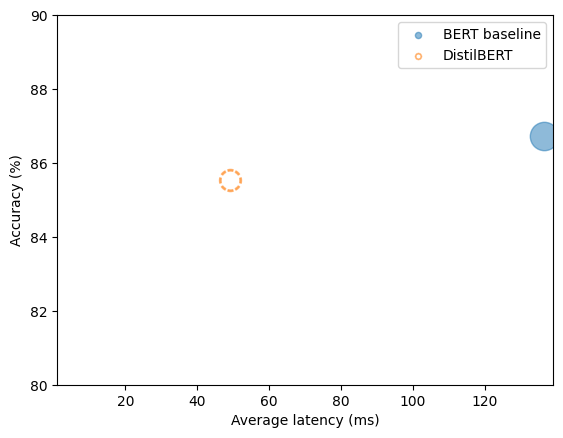

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
def plot_metrics(perf_metrics, current_optim_type):
    df = pd.DataFrame.from_dict(perf_metrics, orient='index')

    for idx in df.index:
        df_opt = df.loc[idx]
        # 현재 최적화 방법을 점선으로 그립니다
        if idx == current_optim_type:
            plt.scatter(df_opt["time_avg_ms"], df_opt["accuracy"] * 100,
                        alpha=0.5, s=df_opt["size_mb"], label=idx,
                        marker='$\u25CC$')
        else:
            plt.scatter(df_opt["time_avg_ms"], df_opt["accuracy"] * 100,
                        s=df_opt["size_mb"], label=idx, alpha=0.5)

    legend = plt.legend(bbox_to_anchor=(1,1))
    for handle in legend.legend_handles:
        handle.set_sizes([20])

    plt.ylim(80,90)
    # 가장 느린 모델을 사용해 x 축 범위를 정합니다
    xlim = int(perf_metrics["BERT baseline"]["time_avg_ms"] + 3)
    plt.xlim(1, xlim)
    plt.ylabel("Accuracy (%)")
    plt.xlabel("Average latency (ms)")
    plt.show()

plot_metrics(perf_metrics, optim_type)

### 8.3.5 옵투나로 좋은 하이퍼파라미터 찾기
- 좋은 $\alpha$ 와 $\mathit{T}$ 값을 찾기 위해 2D 하이퍼파라미터 공간에서 그리드 서치(grid search)를 수행할 수 있다.
- 최적화 프레임워크 Optuna를 사용하는 것이 더 좋은 방법이다.
- Optuna는 search 문제를 여러 시도를 통해 최적화시킬 목적 함수로 표현한다.

##### 로젠브록의 바나나 함수 최소화:
$$f(x, y)=(1-x)^2+100(y-x^2)^2$$

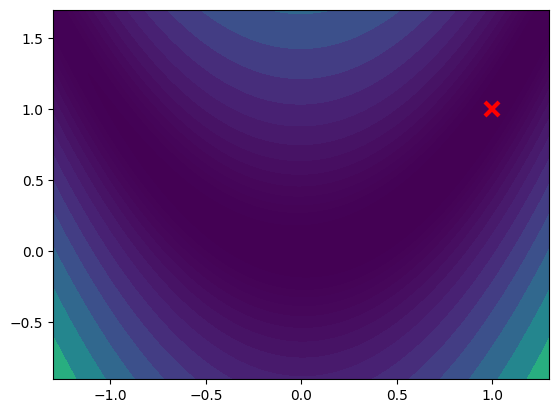

In [ ]:
# 두 변수를 가진 로젠브록(Rosenbrock) 함수 그래프
import matplotlib.pyplot as plt
import numpy as np

def f(x, y):
    return (1-x)**2+100*(y-x**2)**2

X, Y = np.meshgrid(np.linspace(-2, 2, 250), np.linspace(-1, 3, 250))
Z = f(X,Y)
_, ax = plt.subplots()
ax.plot([1], [1], 'x', mew=3, markersize=10, color="red")
ax.contourf(X, Y, Z, np.logspace(-1, 3, 30), cmap='viridis', extend="both")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-0.9, 1.7)
plt.show()

이 바나나 함수는 점 $(1,1)$에서 최솟값을 가지며, 골짜기 영역을 찾는 것은 쉽지만 최솟값으로 수렴하기는 어렵다는 특징을 갖는다.

In [ ]:
def objective(trial):
    x = trial.suggest_float("x", -2, 2)
    y = trial.suggest_float("y", -2, 2)
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2

- `suggest_int`와 `suggest_catagorical` 도 제공

In [ ]:
import optuna

study = optuna.create_study()
study.optimize(objective, n_trials=1000)

[I 2025-06-10 20:05:24,879] A new study created in memory with name: no-name-8ec9ce3c-79b9-4ae2-a033-2271fa08f6f0
[I 2025-06-10 20:05:24,893] Trial 0 finished with value: 43.542529025307026 and parameters: {'x': -1.1632214391094555, 'y': 0.7296821431098812}. Best is trial 0 with value: 43.542529025307026.
[I 2025-06-10 20:05:24,897] Trial 1 finished with value: 10.255176908930348 and parameters: {'x': -1.0550763004101622, 'y': 0.8675879885302877}. Best is trial 1 with value: 10.255176908930348.
[I 2025-06-10 20:05:24,899] Trial 2 finished with value: 21.548075440998893 and parameters: {'x': 0.18755635154721917, 'y': 0.4922114183017774}. Best is trial 1 with value: 10.255176908930348.
[I 2025-06-10 20:05:24,904] Trial 3 finished with value: 25.549851040317275 and parameters: {'x': 0.0642674308797444, 'y': -0.49260157268347315}. Best is trial 1 with value: 10.255176908930348.
[I 2025-06-10 20:05:24,905] Trial 4 finished with value: 28.7340051655953 and parameters: {'x': -0.16564504851382

In [ ]:
study.best_params

{'x': 0.9901680638217588, 'y': 0.9842462886750123}

#### 트랜스포머스에서 옵투나 사용 순서
1) 최적화 하려는 하이퍼파라미터 공간을 정의   
2) Trainer의 hyperparameter_search() 메서드에 시도 횟수, 최적화 방향, 하이퍼라라미터 검색 공간을 전달  
3) BestRun 반환됨  


In [ ]:
def hp_space(trial):
    return {"num_train_epochs": trial.suggest_int("num_train_epochs", 5, 10),
        "alpha": trial.suggest_float("alpha", 0, 1),
        "temperature": trial.suggest_int("temperature", 2, 20)}

In [ ]:
best_run = distilbert_trainer.hyperparameter_search(
    n_trials=5, direction="maximize", hp_space=hp_space)

[I 2025-06-09 23:53:59,819] A new study created in memory with name: no-name-393335a6-7784-4cf5-be0b-a7dbdfac0101


Epoch,Training Loss,Validation Loss,Accuracy
1,3.731000,2.809133,0.731290
2,2.186900,1.481890,0.858387
3,1.162600,0.823587,0.903548
4,0.651400,0.544435,0.923871
5,0.412800,0.420956,0.938065
6,0.300300,0.369596,0.939355
7,0.242400,0.342980,0.941613
8,0.216400,0.336011,0.942581


[I 2025-06-09 23:56:03,068] Trial 0 finished with value: 0.9425806451612904 and parameters: {'num_train_epochs': 8, 'alpha': 0.857517822880121, 'temperature': 15}. Best is trial 0 with value: 0.9425806451612904.


Epoch,Training Loss,Validation Loss,Accuracy
1,3.132500,2.377027,0.727419
2,1.899300,1.348254,0.854194
3,1.115000,0.835018,0.900323
4,0.720300,0.609949,0.918387
5,0.536300,0.512498,0.928710
6,0.460400,0.484087,0.933226


[I 2025-06-09 23:57:35,639] Trial 1 finished with value: 0.9332258064516129 and parameters: {'num_train_epochs': 6, 'alpha': 0.6990033642511424, 'temperature': 15}. Best is trial 0 with value: 0.9425806451612904.


...

[I 2025-06-09 23:59:53,658] Trial 2 finished with value: 0.9438709677419355 and parameters: {'num_train_epochs': 9, 'alpha': 0.9067066876573857, 'temperature': 20}. Best is trial 2 with value: 0.9438709677419355.


Epoch,Training Loss,Validation Loss,Accuracy
1,3.051200,2.312842,0.728065
2,1.848700,1.313489,0.853226
3,1.088200,0.816287,0.900645
4,0.706000,0.598268,0.917742
5,0.527600,0.503214,0.929355
6,0.453900,0.475449,0.932903


[I 2025-06-10 00:01:26,084] Trial 3 finished with value: 0.9329032258064516 and parameters: {'num_train_epochs': 6, 'alpha': 0.6778728782661578, 'temperature': 14}. Best is trial 2 with value: 0.9438709677419355.


Epoch,Training Loss,Validation Loss,Accuracy
1,2.390200,1.808622,0.727742
2,1.473700,1.080420,0.852258
3,0.931300,0.725822,0.895161
4,0.666000,0.576019,0.915806
5,0.557900,0.532360,0.919677


[I 2025-06-10 00:02:43,459] Trial 4 finished with value: 0.9196774193548387 and parameters: {'num_train_epochs': 5, 'alpha': 0.5076254944542328, 'temperature': 19}. Best is trial 2 with value: 0.9438709677419355.


In [ ]:
print(best_run)

BestRun(run_id='2', objective=0.9438709677419355,
hyperparameters={'num_train_epochs': 9, 'alpha': 0.9067066876573857,
'temperature': 20}, run_summary=None)


In [ ]:
for k,v in best_run.hyperparameters.items():
    setattr(student_training_args, k, v)

# 정제된 모델을 저장할 새로운 저장소를 정의합니다
distilled_ckpt = "distilbert-base-uncased-distilled-clinc"
student_training_args.output_dir = distilled_ckpt

# 최적의 매개변수로 새로운 Trainer를 만듭니다
distil_trainer = DistillationTrainer(model_init=student_init,
    teacher_model=teacher_model, args=student_training_args,
    train_dataset=clinc_enc['train'], eval_dataset=clinc_enc['validation'],
    compute_metrics=compute_metrics, tokenizer=student_tokenizer)

distil_trainer.train();

<ipython-input-29-f6fe54c10766>:7: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `DistillationTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy
1,3.911500,2.934268,0.733871
2,2.263400,1.507560,0.860323
3,1.160700,0.805871,0.905806
4,0.616100,0.514995,0.924839
5,0.366200,0.389281,0.938065
6,0.250100,0.340377,0.939677
7,0.189400,0.311459,0.941935
8,0.158100,0.300762,0.943871
9,0.144700,0.297676,0.943871


In [ ]:
distil_trainer.push_to_hub("Training complete")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]

training_args.bin:   0%|          | 0.00/5.43k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/kikim6114/distilbert-base-uncased-distilled-clinc/commit/502d0a345baabc5b4b3bce4c7e2acb1b204c6980', commit_message='Training complete', commit_description='', oid='502d0a345baabc5b4b3bce4c7e2acb1b204c6980', pr_url=None, repo_url=RepoUrl('https://huggingface.co/kikim6114/distilbert-base-uncased-distilled-clinc', endpoint='https://huggingface.co', repo_type='model', repo_id='kikim6114/distilbert-base-uncased-distilled-clinc'), pr_revision=None, pr_num=None)

### 정제 모델 벤치마크 수행하기

In [ ]:
# `kikim6114`를 자신의 허브 사용자 이름으로 바꾸세요.
distilled_ckpt = "kikim6114/distilbert-base-uncased-distilled-clinc"
pipe = pipeline("text-classification", model=distilled_ckpt)
optim_type = "Distillation"
pb = PerformanceBenchmark(pipe, clinc["test"], optim_type=optim_type)
perf_metrics.update(pb.run_benchmark())

config.json:   0%|          | 0.00/8.16k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

모델 크기 (MB) - 255.88
평균 레이턴시 (ms) - 4.60 +\- 0.15
테스트 세트 정확도 - 0.883


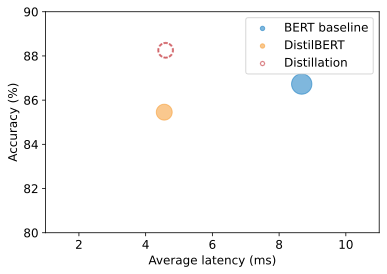

In [ ]:
plot_metrics(perf_metrics, optim_type)

## 8.4 양자화로 모델 속도 높이기

### 사이드바: 부동 소수점 숫자 vs 고정 소수점 숫자
- 고정소수점: $123.456$
- 부동소수점: $1.23456 \times 10^2=0.00123456 \times 10^5=12.3456 \times 10$ ... 등
- 가중치, 활성화, 그래디언트 등은 FP32 또는 FP16과 FP32를 혼합해 표현한다.
#### 고정 소수점



### End sidebar

<img alt="Mapping floating-point numbers to 8-bit integers" width="800" caption="Quantizing floating-point numbers as unsigned 8-bit integers (courtesy of Manas Sahni)" src="https://github.com/kikim6114/nlp-practice-2025/blob/main/images/chapter08_fp32-to-int8.png?raw=1" id="fp32toint8"/> <br>
[그림 8-6] 부동소수점 숫자를 부호 없는 8비트 정수로 양자화하기(Manas Sahni 제공)

#### 양자화의 기본 원리:   
부동소수점 숫자 $f$를 원래 범위 $[f_{max}, f_{min}]$에서 고정소수점 숫자 $q$로 표현된 작은 범위 $[q_{max}, q_{min}]$으로 매핑하고 모든 값을 이 구간에 선형적으로 분포시킨다.
$$f=\left(\frac{f_{max}-f_{min}}{q_{max}-q_{min}}\right)(q-Z)=S(q-Z)$$
여기서,
  - $S$: scale factor
  - $Z$: $q$와 동일한 타입으로, $f=0$ 을 양자화한 값으로서 영점(zero point)라고 함.

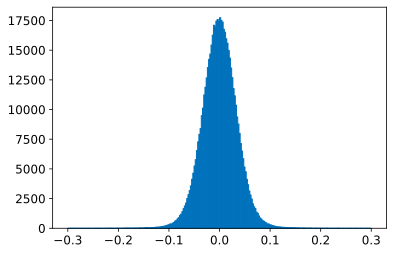

In [ ]:
import matplotlib.pyplot as plt

state_dict = pipe.model.state_dict()
weights = state_dict["distilbert.transformer.layer.0.attention.out_lin.weight"]
plt.hist(weights.flatten().cpu().numpy(), bins=250, range=(-0.3,0.3), edgecolor="C0")
plt.show()

8-bit 정수로 압축한다면,
$[q_{max}, q_{min}]=[-128, 127]$

In [ ]:
zero_point = 0
scale = (weights.max() - weights.min()) / (127 - (-128))

양자화된 텐서 계산:
$$q=\frac{f}{S}+Z$$
를 계산하고, 범위 밖의 값을 클리핑하고, 가장 가까운 정수로 반올림하고, `Tensor.char()` 함수를 사용해 `torch.int8` 타입으로 표현.

In [ ]:
(weights / scale + zero_point).clamp(-128, 127).round().char()

tensor([[ -5,  -8,   0,  ...,  -6,  -4,   8],
        [  9,   2,   1,  ...,  -4,   7,   0],
        [ -9,  -5,   6,  ...,   0,   6,  -4],
        ...,
        [  6,   0,  13,  ...,   0,   6,  -1],
        [  0,  -2, -12,  ...,  12,  -7, -13],
        [-13,  -1,  -9,  ...,   8,   3,  -1]], device='cuda:0',
       dtype=torch.int8)

#### 파이토치의 함수 사용한 양자화:

In [ ]:
from torch import quantize_per_tensor

dtype = torch.qint8
quantized_weights = quantize_per_tensor(weights, scale, zero_point, dtype)
quantized_weights.int_repr()

tensor([[ -5,  -8,   0,  ...,  -6,  -4,   8],
        [  9,   2,   1,  ...,  -4,   7,   0],
        [ -9,  -5,   6,  ...,   0,   6,  -4],
        ...,
        [  6,   0,  13,  ...,   0,   6,  -1],
        [  0,  -2, -12,  ...,  12,  -7, -13],
        [-13,  -1,  -9,  ...,   8,   3,  -1]], device='cuda:0',
       dtype=torch.int8)

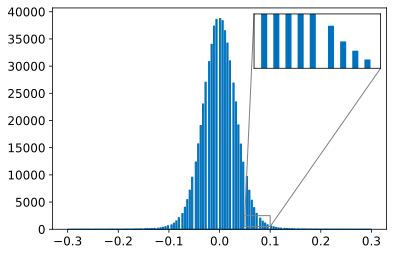

In [ ]:
# 트랜스포머 가중치에서 양자화 효과
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes,mark_inset

# 히스토그램 그리기
fig, ax = plt.subplots()
ax.hist(quantized_weights.dequantize().flatten().cpu().numpy(),
         bins=250, range=(-0.3,0.3), edgecolor="C0");
# 확대 그림 만들기
axins = zoomed_inset_axes(ax, 5, loc='upper right')
axins.hist(quantized_weights.dequantize().flatten().cpu().numpy(),
         bins=250, range=(-0.3,0.3));
x1, x2, y1, y2 = 0.05, 0.1, 500, 2500
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.axes.xaxis.set_visible(False)
axins.axes.yaxis.set_visible(False)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")
plt.show()

In [ ]:
%%timeit
weights @ weights  # FP32 @ FP32

62.6 µs ± 15.2 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [ ]:
weights_cpu = weights.cpu()

In [ ]:
%%timeit
weights_cpu @ weights_cpu  # FP32 @ FP32

1.45 ms ± 196 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


##### 양자화된 텐서 곱

In [ ]:
from torch.nn.quantized import QFunctional

q_fn = QFunctional()

# Move the quantized tensor to CPU before using QFunctional
quantized_weights_cpu = quantized_weights.cpu()

UsageError: Line magic function `%%timeit` not found.


In [ ]:
%%timeit
q_fn.mul(quantized_weights_cpu, quantized_weights_cpu)

55.5 µs ± 1.73 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [ ]:
1.45*1000/55.5

26.126126126126128

가중치 텐서와 양자화된 텐서의 저장 크기 비교

In [ ]:
import sys

sys.getsizeof(weights.untyped_storage()) / sys.getsizeof(quantized_weights.untyped_storage())

3.9995931541403347

트랜스포머의 실제 압축 비율은 어떤 층을 양자화하는지에 따라 달라지며, 보통 선형 층만 양자화 한다. 모든 연산에서 정밀도를 바꾸면 모델 성능에 나쁜 영향을 주므로 주의해야 한다.
#### 신경망에서의 양자화 방법
1) 동적 양자화:
  - 훈련 중에는 적용하지 않으며, 가중치와 활성화값이 추론 직전에 (동적으로) INT8으로 변환
  - 가장 간단한 방법
  - 활성화를 메모리에 읽고 쓸 때 부동소수점 형식을 사용하므로 정밀도 변환이 병목이 될 수 있다.

2) 정적 양자화:
  - 양자화 체계를 사전에 계산해 양자화 변환 부담을 피하는 방법
  - 추론에 앞서 대표적 샘플 데이터에서 활성화 패턴을 관찰하여 수행
  - 대표적 샘플을 찾는 방법이 어려움
  - 훈련과 추론 과정애서 정밀도 차이로 인한 모델 성능 저하 문제 해결이 어려움   

3) 양자화를 고려한 훈련:   
  - 가짜로 FP32 값을 양자화해 훈련 중에 양자화 효과를 시뮬레이션
  - 훈련 중 FP32를 반올림하여 양자화 효과를 흉내낸다.
  - 정방향/역방향 패스 모두에 적용됨 정적/동적 양자화를 모두 사용해 모델 성능을 높인다.

#### 양자화 방법의 선택 기준
- 추론 시 트랜스포머의 주요 병목 지점은 가중치 관련 연산 및 메모리 대역폭
- 따라서 트랜스포머 기반 NLP 모델에서는 동적 양자화가 최상의 선택
- 보다 작은 컴퓨터 비전 모델에서는 정적 양자화
- 병목 현상이 너무 크면 양자화를 고려한 훈련을 사용

#### PyTorch에서 동적 양자화

In [ ]:
from torch.quantization import quantize_dynamic

# `kikim6114`를 자신의 허브 사용자 이름으로 바꾸세요.
model_ckpt = "kikim6114/distilbert-base-uncased-distilled-clinc"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = (AutoModelForSequenceClassification
         .from_pretrained(model_ckpt).to("cpu"))

model_quantized = quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)

### 8.5 양자화된 모델의 벤치마크 수행하기

In [ ]:
pipe = pipeline("text-classification", model=model_quantized,
                tokenizer=tokenizer, device="cpu")
optim_type = "Distillation + quantization"
pb = PerformanceBenchmark(pipe, clinc["test"], optim_type=optim_type)
perf_metrics.update(pb.run_benchmark())

모델 크기 (MB) - 132.39
평균 레이턴시 (ms) - 9.18 +\- 0.86
테스트 세트 정확도 - 0.894


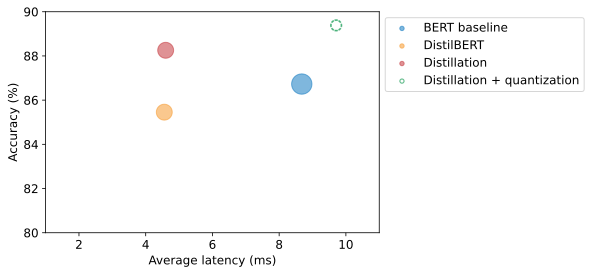

In [ ]:
plot_metrics(perf_metrics, optim_type)

## 8.6 ONNX와 ONNX 런타임으로 추론 최적화하기

#### ONNX(Open Neural Network Exchange) 란?

- 파이토치, 텐서플로 등 다양한 프레임워크에서 딥러닝 모델을 나타내기 위해 공통 연산자와 공통 파일 포맷을 정의하는 공개 표준.
- ONNX는 모델을 중간 계층 형식으로 변환하고 모델을 실행하는 데 필요한 라이브러리를 제공한다.
- 파이토치 모델 $\leftrightarrow$ ONNX $\leftrightarrow$ 텐서플로 모델 임포트 가능

#### ONNX Runtime 이란?

- ONNX 모델을 실행하기 위한 엔진으로서, ONNX 런타임은 빠른 추론을 위한 최적화된 커널을 사용한다.
- CPU, GPU 및 딥러닝 가속기(DNNL, NNAPI, OpenVINO)를 지원.

#### ONNX가 만들어 내는 계산 그래프
- 모델을 ONNX 포맷으로 내보내면 ONNX의 연산자를 사용해 신경망을 통과하는 데이터의 흐름을 표현하기 위해 계산그래프(중간 표현이라고도 함)를 만든다.

<img alt="Example ONNX graph" width="500" caption="A section of the ONNX graph for BERT-base, visualized in Netron" src="https://github.com/kikim6114/nlp-practice-2025/blob/main/images/chapter08_bert-onnx.png?raw=1" id="bert-onnx"/>
<br>
[그림 8-8] Netron으로 시각화한 BERT 기반 모델에 대한 ONNX 그래프의 한 섹션


#### ONNX 런타임
- ONNX 런타임(ORT)는 연산자 융합 상수 폴딩 같은 ONNX 그래프 최적화 도구를 제공
- 여러 종류의 하드웨어에서 모델을 실행하도록 실행 공급자(execution provide)를 위한 인터페이스를 정의하며 이것은 강력한 추상화이다.

<img alt="Architecture of the ONNX and ONNX Runtime ecosystem" width="500" caption="Architecture of the ONNX and ONNX Runtime ecosystem (courtesy of the ONNX Runtime team)" src="https://github.com/kikim6114/nlp-practice-2025/blob/main/images/chapter08_onnx-ort.png?raw=1" id="onnx-ort"/> <br>
[그림 8-9] ONNX와 ONNX 런타임 생태계의 아키텍처(ONNX 런타임 팀 제공)

#### ONNX 실행을 위한 `convert_graph_to_onnx.convert()` 함수가 처리하는 일:
1) 하나의 파이프라인으로 모델을 초기화  
2) ONNX가 계산 그래프를 기록하도록 플레이스홀더 입력으로 파이프라인을 실행  
3) 동적 시퀀스 길이를 처리하기 위해 동적인 축을 정의  
4) 네트워크 파라미터와 함께 이 그래프를 저장  

#### ONNX를 위한 OpenMP 환경 변수를 지정:

In [ ]:
!pip install onnx
!pip install onnxruntime

In [ ]:
import os
from psutil import cpu_count
# from transformers import AutoModelForSequenceClassification, AutoTokenizer # 임시로 작성
# from pathlib import Path

os.environ["OMP_NUM_THREADS"] = f"{cpu_count()}"
os.environ["OMP_WAIT_POLICY"] = "ACTIVE"

In [ ]:
from transformers.convert_graph_to_onnx import convert

# "kikim6114"를 자신의 허브 사용자 이름으로 바꾸세요.
model_ckpt = "kikim6114/distilbert-base-uncased-distilled-clinc"
model = (AutoModelForSequenceClassification
         .from_pretrained(model_ckpt).to("cpu")) # Move model to CPU
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
onnx_model_path = Path("onnx/model.onnx")
convert(framework="pt", model=model_ckpt, tokenizer=tokenizer,
        output=onnx_model_path, opset=12, pipeline_name="text-classification")

/usr/local/lib/python3.11/dist-packages/transformers/convert_graph_to_onnx.py:361: FutureWarning: The `transformers.convert_graph_to_onnx` package is deprecated and will be removed in version 5 of Transformers
  warnings.warn(
Device set to use cpu


ONNX opset version set to: 12
Loading pipeline (model: kikim6114/distilbert-base-uncased-distilled-clinc, tokenizer: DistilBertTokenizerFast(name_or_path='kikim6114/distilbert-base-uncased-distilled-clinc', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normaliz

UnsupportedOperatorError: Exporting the operator 'aten::scaled_dot_product_attention' to ONNX opset version 12 is not supported. Support for this operator was added in version 14, try exporting with this version.

모델을 저장했으므로, 모델에 입력을 전달하기 위해 `InferenceSession` 객체를 만든다.

In [ ]:
from onnxruntime import (GraphOptimizationLevel, InferenceSession,
                         SessionOptions)

def create_model_for_provider(model_path, provider="CPUExecutionProvider"):
    options = SessionOptions()
    options.intra_op_num_threads = 1
    options.graph_optimization_level = GraphOptimizationLevel.ORT_ENABLE_ALL
    session = InferenceSession(str(model_path), options, providers=[provider])
    session.disable_fallback()
    return session

In [ ]:
onnx_model = create_model_for_provider(onnx_model_path)

NameError: name 'onnx_model_path' is not defined

In [ ]:
inputs = clinc_enc["test"][:1]
del inputs["labels"]  # ONNX는 input_ids와 attention_mask 만 입력으로 기대하므로 label 열은 삭제
logits_onnx = onnx_model.run(None, inputs)[0]
logits_onnx.shape

NameError: name 'clinc_enc' is not defined

In [ ]:
np.argmax(logits_onnx)

61

In [ ]:
clinc_enc["test"][0]["labels"]

61

ONNX 모델은 text_classification 파이프라인과 호환되지 않으므로 핵심 동작을 흉내 재는 사용자 정의 클래스를 만들자.

In [ ]:
from scipy.special import softmax

class OnnxPipeline:
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer

    def __call__(self, query):
        model_inputs = self.tokenizer(query, return_tensors="pt")
        inputs_onnx = {k: v.cpu().detach().numpy()
                       for k, v in model_inputs.items()}
        logits = self.model.run(None, inputs_onnx)[0][0, :]
        probs = softmax(logits)
        pred_idx = np.argmax(probs).item()
        return [{"label": intents.int2str(pred_idx), "score": probs[pred_idx]}]

In [ ]:
pipe = OnnxPipeline(onnx_model, tokenizer)
pipe(query)

[{'label': 'car_rental', 'score': 0.57666945}]

In [ ]:
class OnnxPerformanceBenchmark(PerformanceBenchmark):
    def __init__(self, *args, model_path, **kwargs):
        super().__init__(*args, **kwargs)
        self.model_path = model_path

    def compute_size(self):
        size_mb = Path(self.model_path).stat().st_size / (1024 * 1024)
        print(f"모델 크기 (MB) - {size_mb:.2f}")
        return {"size_mb": size_mb}

In [ ]:
optim_type = "Distillation + ORT"
pb = OnnxPerformanceBenchmark(pipe, clinc["test"], optim_type,
                              model_path="onnx/model.onnx")
perf_metrics.update(pb.run_benchmark())

모델 크기 (MB) - 255.98
평균 레이턴시 (ms) - 23.42 +\- 0.58
테스트 세트 정확도 - 0.857


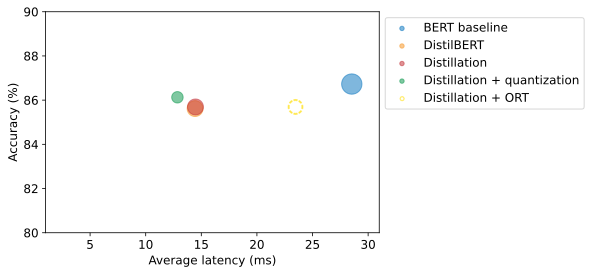

In [ ]:
plot_metrics(perf_metrics, optim_type)

In [ ]:
from onnxruntime.quantization import quantize_dynamic, QuantType

model_input = "onnx/model.onnx"
model_output = "onnx/model.quant.onnx"
quantize_dynamic(model_input, model_output, weight_type=QuantType.QInt8)

Ignore MatMul due to non constant B: /[/distilbert/transformer/layer.0/attention/MatMul]
Ignore MatMul due to non constant B: /[/distilbert/transformer/layer.0/attention/MatMul_1]
Ignore MatMul due to non constant B: /[/distilbert/transformer/layer.1/attention/MatMul]
Ignore MatMul due to non constant B: /[/distilbert/transformer/layer.1/attention/MatMul_1]
Ignore MatMul due to non constant B: /[/distilbert/transformer/layer.2/attention/MatMul]
Ignore MatMul due to non constant B: /[/distilbert/transformer/layer.2/attention/MatMul_1]
Ignore MatMul due to non constant B: /[/distilbert/transformer/layer.3/attention/MatMul]
Ignore MatMul due to non constant B: /[/distilbert/transformer/layer.3/attention/MatMul_1]
Ignore MatMul due to non constant B: /[/distilbert/transformer/layer.4/attention/MatMul]
Ignore MatMul due to non constant B: /[/distilbert/transformer/layer.4/attention/MatMul_1]
Ignore MatMul due to non constant B: /[/distilbert/transformer/layer.5/attention/MatMul]
Ignore MatM

In [ ]:
onnx_quantized_model = create_model_for_provider(model_output)
pipe = OnnxPipeline(onnx_quantized_model, tokenizer)
optim_type = "Distillation + ORT (quantized)"
pb = OnnxPerformanceBenchmark(pipe, clinc["test"], optim_type,
                              model_path=model_output)
perf_metrics.update(pb.run_benchmark())

모델 크기 (MB) - 64.36
평균 레이턴시 (ms) - 12.60 +\- 0.57
테스트 세트 정확도 - 0.855


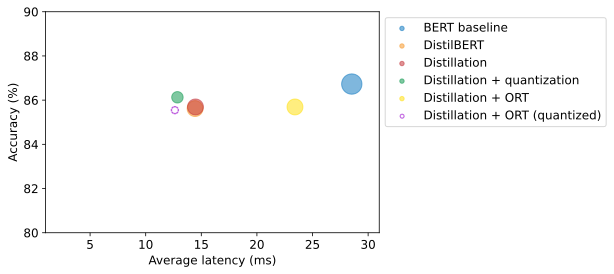

In [ ]:
plot_metrics(perf_metrics, optim_type)

## 8.7 가중치 가지치기로 희소한 모델 만들기
신경망에서 가장 덜 중요한 가중치를 찾아 제거하는 방식으로 모델의 파라미터 개수를 줄이는 방법

### 8.7.1 심층 신경망의 희소성
- 모델이 점차 희소화되며, 희소 행렬 포맷으로 저장된다
- 지치기와 양자화를 함께 사용하면 추가 압축이 가능하다

<img alt="Network Pruning" width="500" caption="Weights and neurons before and after pruning (courtesy of Song Han)" src="https://github.com/kikim6114/nlp-practice-2025/blob/main/images/chapter08_network-pruning.png?raw=1" id="network-pruning"/> <br>
[그림 8-10] 가지치기 전후의 가중치와 뉴런(Song Han 제공)

### 8.7.1 가중치 가지치기 방법


$$\text{Top}_k(\mathbf{S})_{ij}=\begin{cases} 1 & S_{ij}가 \, 최상위\, k \%인\, 경우, \\ 0 & 그\, 외의\, 경우 \end{cases} $$

- $\mathbf{S}$: 중요도 점수(importance scores) 행렬
- $k$: 희소성 비율을 제어하는 하이퍼파라미터($k$가 작을수록 행렬이 더 희소해진다).
- 이 점수를 사용해 마스크 행렬(mask matrix) $\mathbf{M}$을 만든다. 이 행렬은 정방향 패스에서 입력 $x_i$에 곱해지는 가중치 $W_{ij}$를 마스킹해 희소한 활성화 $a_i$를 만든다:

$$a_i = \sum_{j}{W_{ij}M_{ij}x_j}$$


#### 가지치기에서 고려할 것들
- 어떤 가중치를 삭제할 것인가?
- 최상의 성능을 내려면 남은 가중치를 어떻게 조정해야 하는가?
- 이런 가지치기 계산을 효율적으로 수행하는 방법은 무엇인가?

#### 절댓값 가지치기
1. 중요도 점수 행렬을 학습한다: $ \mathbf{S}=(|W_{ij}|)_{1 \le j,\, j \le n} $
2. 마스크 행렬을 만든다: $\mathbf{\text M}=\text{Top}_k(\mathbf{S})$  
3. 원하는 희소성에 도달하지 않았으면 1 단계로 간다.

#### 가지치기에 사용되는 세제곱 희소성 스케줄러
- 희소성 초기값 $s_i$에서 출발하여 매 $\Delta t$ 스텝마다 $s_i$를 증가시켜 $N$ 단계 후에 희소성 최종값 $s_f$ 도달하게 한다.  
- 매 $\Delta t$ 스텝마다 이진 마스크 $\mathbf{\text M}$ 을 업데이트해 훈련하는 동안 마스킹된 가중치를 다시 활성화하고 가지치기로 인해 발행할지 모를 잠재적 정확도 손실을 복구하는 방법을 사용한다:

$$ s_t = s_f + (s_i - s_f)\left(1-\frac{t-t_0}{N\Delta t}\right)^3, \,\,\,\, t \in \{t_0, t_0+\Delta t, ..., N\Delta t \}$$

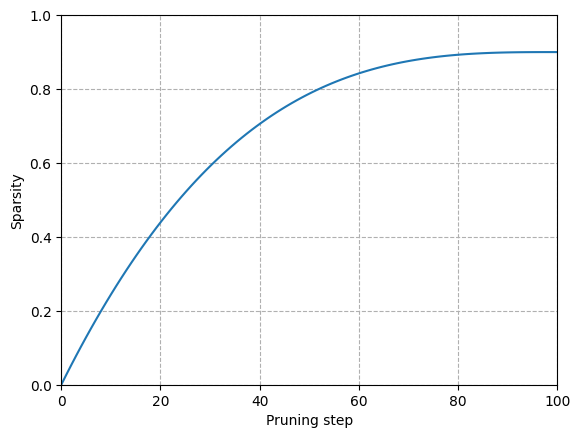

In [ ]:
# 가지치기에 사용되는 세제곱 희소성 스케줄러
import numpy as np
import matplotlib.pyplot as plt

def _sparsity(t, t_0=0, dt=1, s_i=0, s_f=0.9, N=100):
    return s_f + (s_i - s_f) * (1 - (t - t_0) / (N * dt))**3

steps = np.linspace(0,100,100)
values = [_sparsity(t) for t in steps]

fig, ax = plt.subplots()
ax.plot(steps, values)
ax.set_ylim(0,1)
ax.set_xlim(0,100)
ax.set_xlabel("Pruning step")
ax.set_ylabel("Sparsity")
plt.grid(linestyle="dashed")
plt.show()

전이 학습에서는 가중치의 중요도가 주로 사전 훈련 단계에서 결정된다. 따라서 절댓값 가지치기로 인해 미세 튜닝 작업에서 중요한 가중치가 삭제될 수도 있다.

#### 이동 가지치기
- 미세튜닝하는 동안 점진적으로 가중치를 제거해 모델을 점차 희소하게 만든다.
- 미세튜닝 동안 가중치와 점수가 모두 학습된다
- 원점으로부터 가장 크게 이동하는 가중치가 가장 중요한 가중치다.


<img alt="Magnitude vs Movement Pruning" width="700" caption="Comparison of weights removed (in gray) during magnitude pruning (left) and movement pruning (right)" src="https://github.com/kikim6114/nlp-practice-2025/blob/main/images/chapter08_magnitude-vs-movement.png?raw=1" id="magnitude-vs-movement"/> <br>
[그림 8-12] 절댓값 가지치기(왼쪽)와 이동 가지치기(오른쪽)에서 삭제된 가중치 비교

<img alt="Pruning Distributions" width="500" caption="Distribution of remaining weights for magnitude pruning (MaP) and movement pruning (MvP)" src="https://github.com/kikim6114/nlp-practice-2025/blob/main/images/chapter08_pruning-dists.png?raw=1" id="pruning-dists"/> <br>
[그림 8-13] 절댓값 가지치기(MaP)와 이동 가지치기(MvP)에서 남은 가중치

- 트랜스포머스는 기본적으로 가지치기 방법을 제공하지 않음.
- 원래 이동 가지치기를 확장한 방법이 [`nn_pruning`(Neural Networks Block Movement Pruning)](https://huggingface.github.io/nn_pruning/) 라이브러리에 구현되어 있음.
- 성능 최적화에 관심이 있다면 허깅페이스 [🤗 Optimum](https://huggingface.co/docs/optimum/v1.2.1/en/index)을 시도해보는 것도 좋겠다.

## 결론
#### 작지만 빠르고 정확도 높은 모델이 필요하다면?
#### 예측 속도를 높이고 트랜스포머 모델의 메모리 사용량을 줄이는 기술 4 가지:
- 지식 정제(Knowledge Distillation)
- 양자화(Quantization)
- ONNX 포맷과 ONNX 런타임(ORT)을 사용한 그래프 최적화(Graph Optimization)
- 가지치기(Pruning)
  - 트랜스포머 모델의 저장 크기를 줄이는 가장 효과적인 방법이지만,
  - 하드웨어가 희소행렬 연산에 최적화되어야 가지치기의 효과를 제대로 볼 수 있다.

그러나, 레이턴시 요구사항을 맞추려고 해쓰고 있거나, 모델이 컴퓨팅 자원을 독식하고 있다면 이러한 기법 중 하나를 시도해보기를 권한다.///